# 03 · Baseline Collaborative Filtering

Train and evaluate User-Based CF with cosine similarity. Explore neighbourhood sizes, rating predictions, and top-K recommendations.

In [ ]:
import sys

sys.path.insert(0, '..')

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import load_npz

from config import MODELS_DIR, PROCESSED_DIR, REPORTS_DIR, SPLITS_DIR, TOP_K
from src.models.collaborative_filtering import UserBasedCF, mae, rmse

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1 · Load Data

In [2]:
print('Loading data...')
train   = pd.read_parquet(SPLITS_DIR / 'train.parquet')
val     = pd.read_parquet(SPLITS_DIR / 'val.parquet')
test    = pd.read_parquet(SPLITS_DIR / 'test.parquet')
int_mat = load_npz(str(PROCESSED_DIR / 'interaction_matrix.npz'))

print(f'Train : {len(train):,} | Val : {len(val):,} | Test : {len(test):,}')
print(f'Matrix: {int_mat.shape} | nnz: {int_mat.nnz:,}')

Loading data...
Train : 688,779 | Val : 73,940 | Test : 177,371
Matrix: (29474, 7642) | nnz: 688,779


## 2 · Train Model

In [3]:
model = UserBasedCF(n_neighbors=50)

t0 = time.time()
model.fit(int_mat)
fit_time = time.time() - t0
print(f'Fit time: {fit_time:.1f}s')

UserBasedCF fit on 29,474 users × 7,642 movies
Computing user-user cosine similarity...
Similarity matrix ready.
Fit time: 6.2s


## 3 · Similarity Matrix Inspection

Similarity matrix shape: (29474, 29474)
Min sim   : 0.0000
Max sim   : 1.0000
Mean sim  : 0.0887


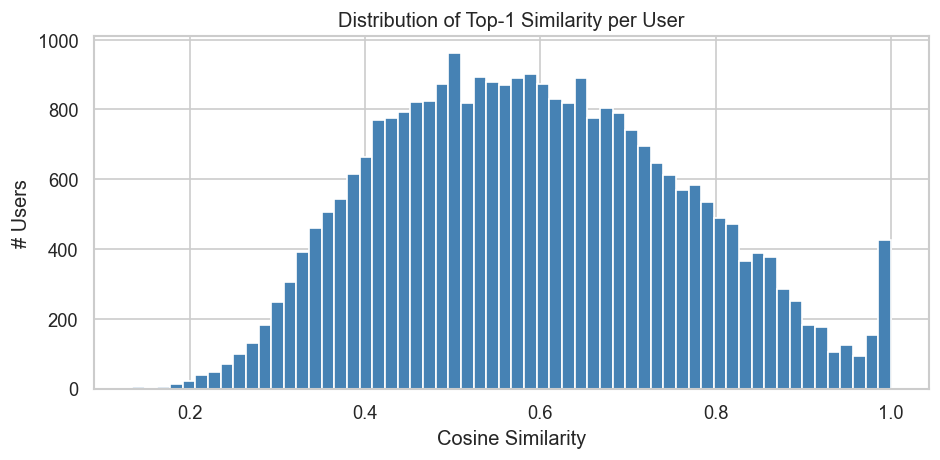

In [4]:
sim = model.user_sim
print(f'Similarity matrix shape: {sim.shape}')
print(f'Min sim   : {sim.min():.4f}')
print(f'Max sim   : {sim.max():.4f}')
print(f'Mean sim  : {sim.mean():.4f}')

# Distribution of top-1 similarities per user
top1_sim = np.sort(sim, axis=1)[:, -1]

plt.figure(figsize=(8, 4))
plt.hist(top1_sim, bins=60, color='steelblue', edgecolor='white')
plt.title('Distribution of Top-1 Similarity per User')
plt.xlabel('Cosine Similarity')
plt.ylabel('# Users')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cf_top1_similarity.png')
plt.show()

In [5]:
# Show most similar users to user 0
user_id = 0
top10_neighbours = np.argsort(sim[user_id])[::-1][:10]
print(f'Top-10 neighbours of user {user_id}:')
for rank, nbr in enumerate(top10_neighbours, 1):
    print(f'  {rank:2d}. user_idx={nbr:5d}  sim={sim[user_id, nbr]:.4f}')

Top-10 neighbours of user 0:
   1. user_idx=18325  sim=0.5036
   2. user_idx=21019  sim=0.4946
   3. user_idx= 8173  sim=0.4933
   4. user_idx=21233  sim=0.4890
   5. user_idx= 2571  sim=0.4873
   6. user_idx= 5060  sim=0.4778
   7. user_idx= 7748  sim=0.4759
   8. user_idx= 7658  sim=0.4745
   9. user_idx=16003  sim=0.4701
  10. user_idx=19471  sim=0.4693


## 4 · Rating Prediction Evaluation

In [6]:
print('Evaluating on 2,000 validation samples...')
val_sample = val.sample(2000, random_state=42)

t0 = time.time()
preds  = model.predict_batch(val_sample)
elapsed = time.time() - t0

y_true = val_sample['rating'].values

val_rmse = rmse(y_true, preds)
val_mae  = mae(y_true, preds)

print(f'Predict time : {elapsed:.1f}s')
print(f'RMSE         : {val_rmse:.4f}')
print(f'MAE          : {val_mae:.4f}')

Evaluating on 2,000 validation samples...
Predict time : 2.9s
RMSE         : 1.1126
MAE          : 0.9088


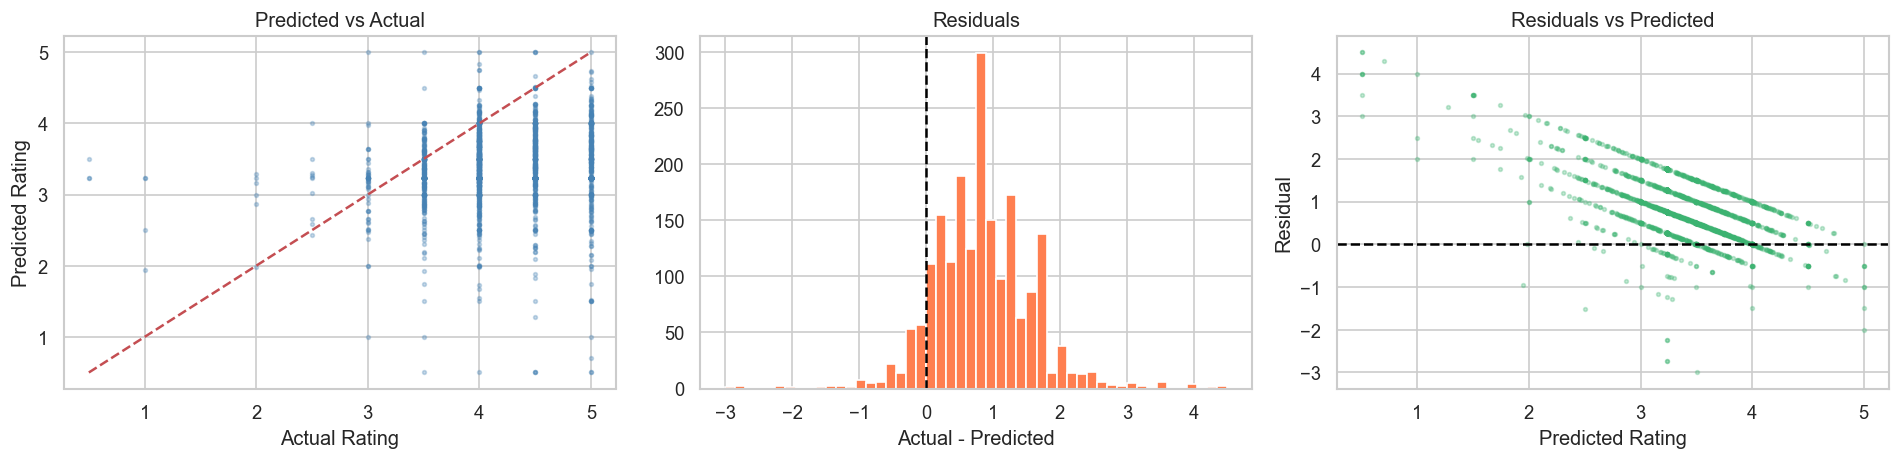

In [7]:
# Residual analysis
residuals = y_true - preds

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y_true, preds, alpha=0.3, s=5, color='steelblue')
axes[0].plot([0.5, 5], [0.5, 5], 'r--')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')

axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residuals')
axes[1].set_xlabel('Actual - Predicted')

axes[2].scatter(preds, residuals, alpha=0.3, s=5, color='mediumseagreen')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title('Residuals vs Predicted')
axes[2].set_xlabel('Predicted Rating')
axes[2].set_ylabel('Residual')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cf_residuals.png')
plt.show()

## 5 · Effect of Neighbourhood Size

In [8]:
# We already have the similarity matrix — sweep n_neighbors without refitting
k_values   = [5, 10, 20, 30, 50, 75, 100]
rmse_list  = []
mae_list   = []

for k in k_values:
    model.n_neighbors = k
    preds_k  = model.predict_batch(val_sample)
    rmse_list.append(rmse(y_true, preds_k))
    mae_list.append(mae(y_true, preds_k))
    print(f'K={k:>3}  RMSE={rmse_list[-1]:.4f}  MAE={mae_list[-1]:.4f}')

best_k = k_values[np.argmin(rmse_list)]
print(f'\nBest K (by RMSE): {best_k}')
model.n_neighbors = best_k  # restore best

K=  5  RMSE=1.2178  MAE=1.0129
K= 10  RMSE=1.1986  MAE=0.9824
K= 20  RMSE=1.1938  MAE=0.9677
K= 30  RMSE=1.1522  MAE=0.9379
K= 50  RMSE=1.1126  MAE=0.9088
K= 75  RMSE=1.1072  MAE=0.9043
K=100  RMSE=1.0911  MAE=0.8968

Best K (by RMSE): 100


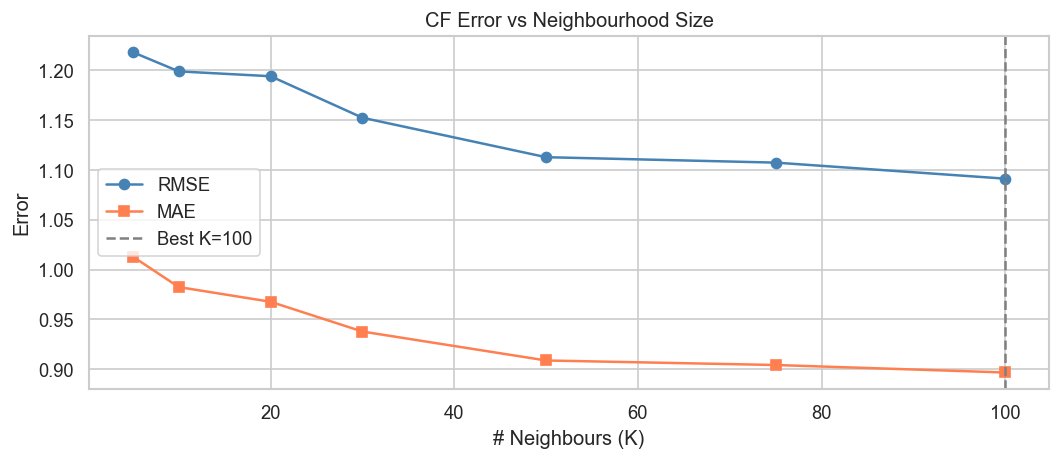

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, rmse_list, 'o-', label='RMSE', color='steelblue')
ax.plot(k_values, mae_list,  's-', label='MAE',  color='coral')
ax.axvline(best_k, color='gray', linestyle='--', label=f'Best K={best_k}')
ax.set_xlabel('# Neighbours (K)')
ax.set_ylabel('Error')
ax.set_title('CF Error vs Neighbourhood Size')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cf_neighbourhood_sweep.png')
plt.show()

## 6 · Top-K Recommendations

In [15]:
# Quick ranking evaluation on a subset of users
from src.evaluation.metrics import evaluate_ranking

test_users  = test['user_idx'].unique()[:200]
ground_truth = (
        test[test["rating"] >= 4.0]
        .groupby("user_idx")["movie_idx"]
        .apply(list)
        .to_dict()
    )

print('Generating top-20 recs for 200 test users...')
t0 = time.time()
recommendations = {}
for u in test_users:
    recommendations[u] = model.recommend(u, top_k=20, exclude_seen=True)
elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s')

results = evaluate_ranking(recommendations, ground_truth, k_values=TOP_K)
print('\nRanking Metrics:')
print(results.round(4))

Generating top-20 recs for 200 test users...
Done in 1.8s

Ranking Metrics:
    Precision@K  Recall@K  NDCG@K     MAP     MRR
K                                                
5        0.0013    0.0021  0.0021  0.0017  0.0027
10       0.0010    0.0028  0.0023  0.0017  0.0027
20       0.0007    0.0035  0.0025  0.0017  0.0027


In [16]:
# Visualize recommendations for a specific user
sample_user = test_users[0]
recs = model.recommend(sample_user, top_k=10)

movie_meta = train[['movie_idx', 'title']].drop_duplicates('movie_idx').set_index('movie_idx')

print(f'Top-10 recommendations for user_idx={sample_user}:')
for rank, mid in enumerate(recs, 1):
    title = movie_meta.loc[mid, 'title'] if mid in movie_meta.index else f'movie_{mid}'
    print(f'  {rank:2d}. [{mid:5d}] {title}')

Top-10 recommendations for user_idx=0:
   1. [ 1152] Guardians of the Galaxy 2 (2017)
   2. [ 1012] Kingsman: The Secret Service (2015)
   3. [  984] The Hobbit: The Battle of the Five Armies (2014)
   4. [ 1151] Thor: Ragnarok (2017)
   5. [ 3064] Zootopia (2016)
   6. [  633] Dawn of the Planet of the Apes (2014)
   7. [ 1155] Untitled Spider-Man Reboot (2017)
   8. [ 1794] Inside Out (2015)
   9. [  775] John Wick (2014)
  10. [ 3973] Arrival (2016)


## 7 · Save Model

In [17]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model.save(MODELS_DIR / 'user_based_cf.pkl')
print('Model saved.')

Model saved → c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\user_based_cf.pkl
Model saved.


## 8 · Summary

In [18]:
print('=== User-Based CF Summary ===')
print(f'Best neighbourhood K : {best_k}')
print(f'Validation RMSE      : {min(rmse_list):.4f}')
print(f'Validation MAE       : {mae_list[k_values.index(best_k)]:.4f}')
print()
print('Strengths  : No training needed, interpretable neighbours')
print('Weaknesses : O(n²) similarity computation, slow for large n, poor cold-start')
print('Next       : Matrix Factorization (SVD) — faster, lower RMSE')

=== User-Based CF Summary ===
Best neighbourhood K : 100
Validation RMSE      : 1.0911
Validation MAE       : 0.8968

Strengths  : No training needed, interpretable neighbours
Weaknesses : O(n²) similarity computation, slow for large n, poor cold-start
Next       : Matrix Factorization (SVD) — faster, lower RMSE
